# Study sites, land use and nitrogen rasters

Retrieve ready-to-use rasters for an area of interest from *NatureDataCube*: `ndc_sites()`, `get_landuse_raster()` and `get_nitrogen_raster()`.

**Requires:** `NDC_TOKEN` environment variable

**Approximate runtime:** about 1 minute

**Author:** Bruno Marcos

**Created in:** October 2, 2026

## Settings

In [1]:
# Load packages
pkgs <- c("sf", "terra", "rNDC")
suppressPackageStartupMessages(
  invisible(lapply(pkgs, FUN = library, character.only = TRUE))
)

## 1. Study sites

`ndc_sites()` lists the study sites bundled with the package, and returns the boundaries of one of them when a name is given.

In [2]:
ndc_sites()

[1] "nutnet_poly"                           
[2] "nestkasten_vlieland_poly"              
[3] "nestkasten_veluwe_poly"                
[4] "nestkasten_liesbosch_poly"             
[5] "nestkasten_boslust_poly"               
[6] "nestkasten_bennekom_poly"              
[7] "loobos"                                
[8] "20251008_licht_op_natuur_lantaarnpalen"


Simple feature collection with 1 feature and 0 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 5.706219 ymin: 52.14783 xmax: 5.785891 ymax: 52.18321
Geodetic CRS:  WGS 84
                            geom
1 MULTIPOLYGON (((5.706219 52...


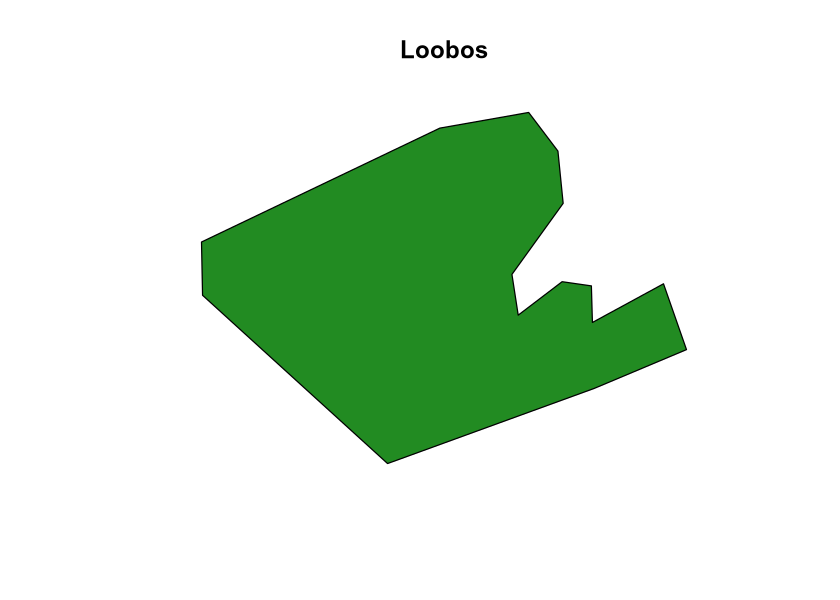

In [3]:
site <- ndc_sites("loobos")
print(site)
plot(st_geometry(site), col = "forestgreen", main = "Loobos")

## 2. Land use

`get_landuse_raster()` downloads the LGN land use raster for an area of interest (clipped to the area) and returns a list with the raster (`stack`), the downloaded `files` and the item `metadata`.

In [4]:
landuse <- get_landuse_raster(site, year = 2024)
print(landuse$stack)
landuse$metadata[, c("id", "title", "observation_date")]

class       : SpatRaster
size        : 798, 1099, 1  (nrow, ncol, nlyr)
resolution  : 5, 5  (x, y)
extent      : 685060, 690555, 5781015, 5785005  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631)
source(s)   : memory
varname     : LGN_2024
name        : LGN_2024
min value   :        1
max value   :      333
# A tibble: 1 × 3
  id              title                  observation_date
  <chr>           <chr>                  <chr>           
1 ndc-lgn2024_05m LGN Land Use 2024 (5m) 2024-01-01      


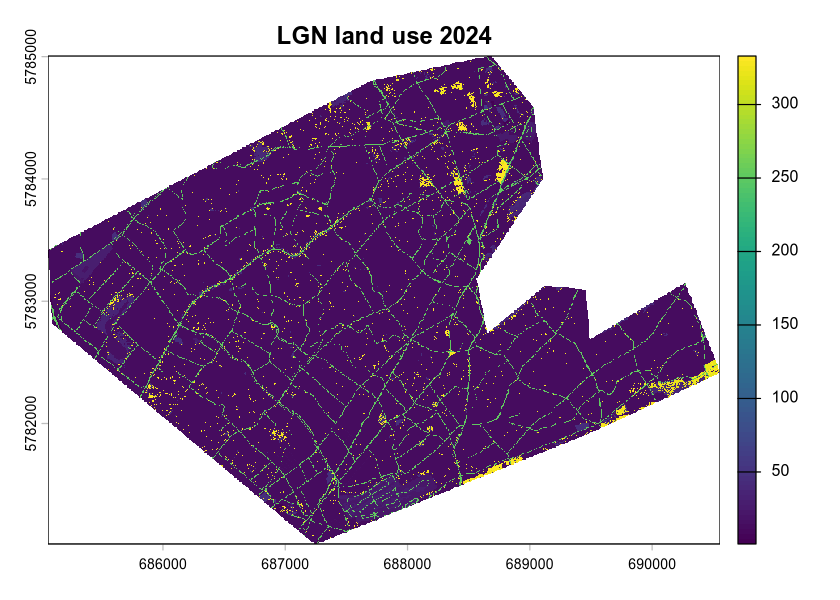

In [5]:
plot(landuse$stack, main = "LGN land use 2024")

## 3. Nitrogen

`get_nitrogen_raster()` downloads the total nitrogen deposition (`ntot`), nitrogen oxides concentration (`nox`) and ammonia concentration (`nh3`) rasters for a given year (2024, 2025 or 2040), clipped to the area of interest.

In [6]:
nitrogen <- get_nitrogen_raster(site, year = 2025)
print(nitrogen$stack)
nitrogen$metadata[, c("layer", "year", "title")]

class       : SpatRaster
size        : 4, 5, 3  (nrow, ncol, nlyr)
resolution  : 1000, 1000  (x, y)
extent      : 685000, 690000, 5781000, 5785000  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631)
source(s)   : memory
varnames    : ntot_2025
              nox_2025
              nh3_2025
names       : ntot_2025, nox_2025, nh3_2025
min values  :      1253,    8.183,    4.033
max values  :      2140,    11.04,    9.931
# A tibble: 3 × 3
  layer year  title                                   
  <chr> <chr> <chr>                                   
1 ntot  2025  Total Nitrogen Deposition (NTOT) 2025   
2 nox   2025  Nitrogen Oxides Concentration (NOx) 2025
3 nh3   2025  Ammonia Concentration (NH3) 2025        


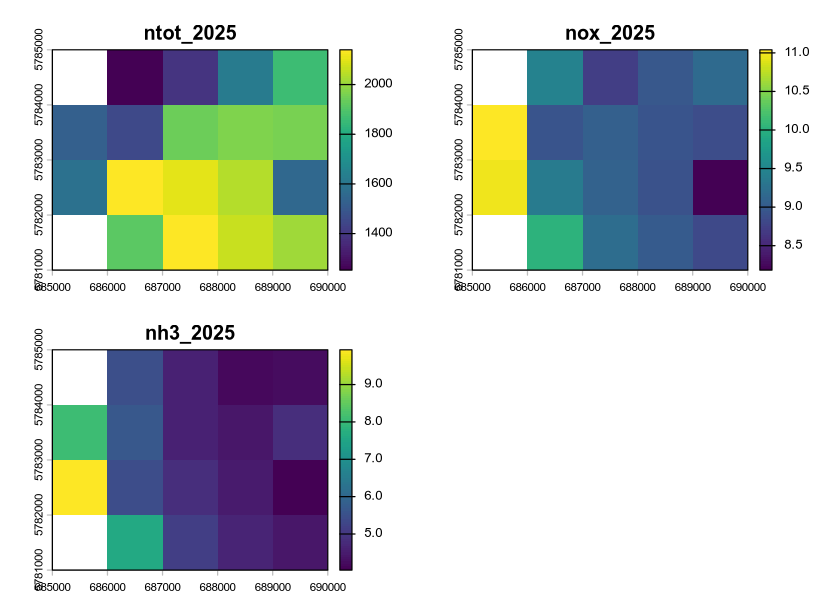

In [7]:
plot(nitrogen$stack)

In [8]:
nitrogen_2040 <- get_nitrogen_raster(site, year = 2040, layers = "ntot")
global(c(nitrogen$stack[["ntot_2025"]], nitrogen_2040$stack), "mean", na.rm = TRUE)

              mean
ntot_2025 1804.833
ntot_2040 1300.539
